# Evaluation Framework — Complete Guide
### Machine-Learning Algorithm Selection Framework | Notebook 5 of 6

> **Companion notebook to:** *A Reproducible Framework for Machine Learning Algorithm Selection* (Alsammani, Delaware State University)

> **Evaluation methodology is as consequential as algorithm choice.** Inappropriate metrics, leaky validation, or absent statistical testing lead to misleading reported results.

This notebook covers the full evaluation pipeline:

1. Classification metrics: Accuracy, F1, MCC, AUC-ROC, AUC-PR, Log Loss, ECE
2. Regression metrics: MSE, RMSE, MAE, $R^2$, sMAPE
3. Cross-validation design: stratified, time-series, nested
4. Statistical significance testing: paired $t$-test, Wilcoxon, McNemar, Friedman-Nemenyi
5. Fairness-aware assessment: demographic parity, equal opportunity, equalized odds


---
## Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import combinations

from sklearn.datasets import load_breast_cancer, load_diabetes, load_iris, make_classification
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, cross_validate, GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score, log_loss,
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve,
    mean_squared_error, mean_absolute_error, r2_score
)

plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white',
                     'axes.spines.top': False, 'axes.spines.right': False})
SEED = 42
np.random.seed(SEED)
print('Setup complete.')


Setup complete.


---
# 1. Classification Metrics
## Complete Reference

Given the confusion matrix (TP, FP, TN, FN):

| Metric | Formula | Notes |
|---|---|---|
| Accuracy | $(TP+TN)/n$ | Misleading under class imbalance |
| Precision | $TP/(TP+FP)$ | Correctness of positive predictions |
| Recall (TPR) | $TP/(TP+FN)$ | Coverage of true positives |
| $F_\beta$ | $(1+\beta^2)\cdot\text{Prec}\cdot\text{Rec}/(\beta^2\text{Prec}+\text{Rec})$ | $\beta=1$: balanced; $\beta=2$: recall-heavy |
| MCC | $\frac{TP\cdot TN - FP\cdot FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$ | Balanced; best for imbalanced data |
| AUC-ROC | $P(\hat{p}_+ > \hat{p}_-)$ | Threshold-independent; ranking quality |
| AUC-PR | Area under Precision-Recall curve | More informative under severe imbalance |
| Log Loss | $-\frac{1}{n}\sum[y\log\hat{p}+(1-y)\log(1-\hat{p})]$ | Calibration quality |
| ECE | $\sum_m \frac{|B_m|}{n}|\text{acc}(B_m)-\text{conf}(B_m)|$ | Expected calibration error |


In [2]:
# Helper: Matthews Correlation Coefficient
def mcc_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    if cm.shape != (2, 2): return 0.0
    TP, FP, FN, TN = cm[1,1], cm[0,1], cm[1,0], cm[0,0]
    denom = np.sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN))
    return (TP*TN - FP*FN) / denom if denom > 0 else 0.0

# Dataset
cancer = load_breast_cancer()
X, y   = cancer.data, cancer.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

models_eval = {
    'Logistic Reg.': Pipeline([('sc', StandardScaler()),
                                ('m', LogisticRegression(max_iter=1000, random_state=SEED))]),
    'Random Forest':  RandomForestClassifier(n_estimators=200, random_state=SEED),
    'Decision Tree':  DecisionTreeClassifier(max_depth=5, random_state=SEED),
    'Gradient Boost': GradientBoostingClassifier(n_estimators=200, random_state=SEED),
    'Naive Bayes':    GaussianNB(),
}

rows = []
for name, model in models_eval.items():
    model.fit(X_train, y_train)
    yp  = model.predict(X_test)
    ypr = model.predict_proba(X_test)[:, 1]
    rows.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, yp), 4),
        'Precision': round(precision_score(y_test, yp), 4),
        'Recall':    round(recall_score(y_test, yp), 4),
        'F1':        round(f1_score(y_test, yp), 4),
        'MCC':       round(mcc_score(y_test, yp), 4),
        'AUC-ROC':   round(roc_auc_score(y_test, ypr), 4),
        'AUC-PR':    round(average_precision_score(y_test, ypr), 4),
        'Log Loss':  round(log_loss(y_test, ypr), 4),
    })

df_m = pd.DataFrame(rows).set_index('Model')
print('-- Classification Metrics: Breast Cancer --')
print(df_m.to_string())


-- Classification Metrics: Breast Cancer --
                Accuracy  Precision  Recall      F1     MCC  AUC-ROC  AUC-PR  Log Loss
Model                                                                                 
Logistic Reg.     0.9825     0.9861  0.9861  0.9861  0.9623   0.9954  0.9971    0.0777
Random Forest     0.9561     0.9589  0.9722  0.9655  0.9054   0.9931  0.9960    0.1118
Decision Tree     0.9211     0.9565  0.9167  0.9362  0.8341   0.9163  0.9202    1.9708
Gradient Boost    0.9561     0.9467  0.9861  0.9660  0.9058   0.9897  0.9940    0.1772
Naive Bayes       0.9386     0.9452  0.9583  0.9517  0.8676   0.9878  0.9926    0.3713


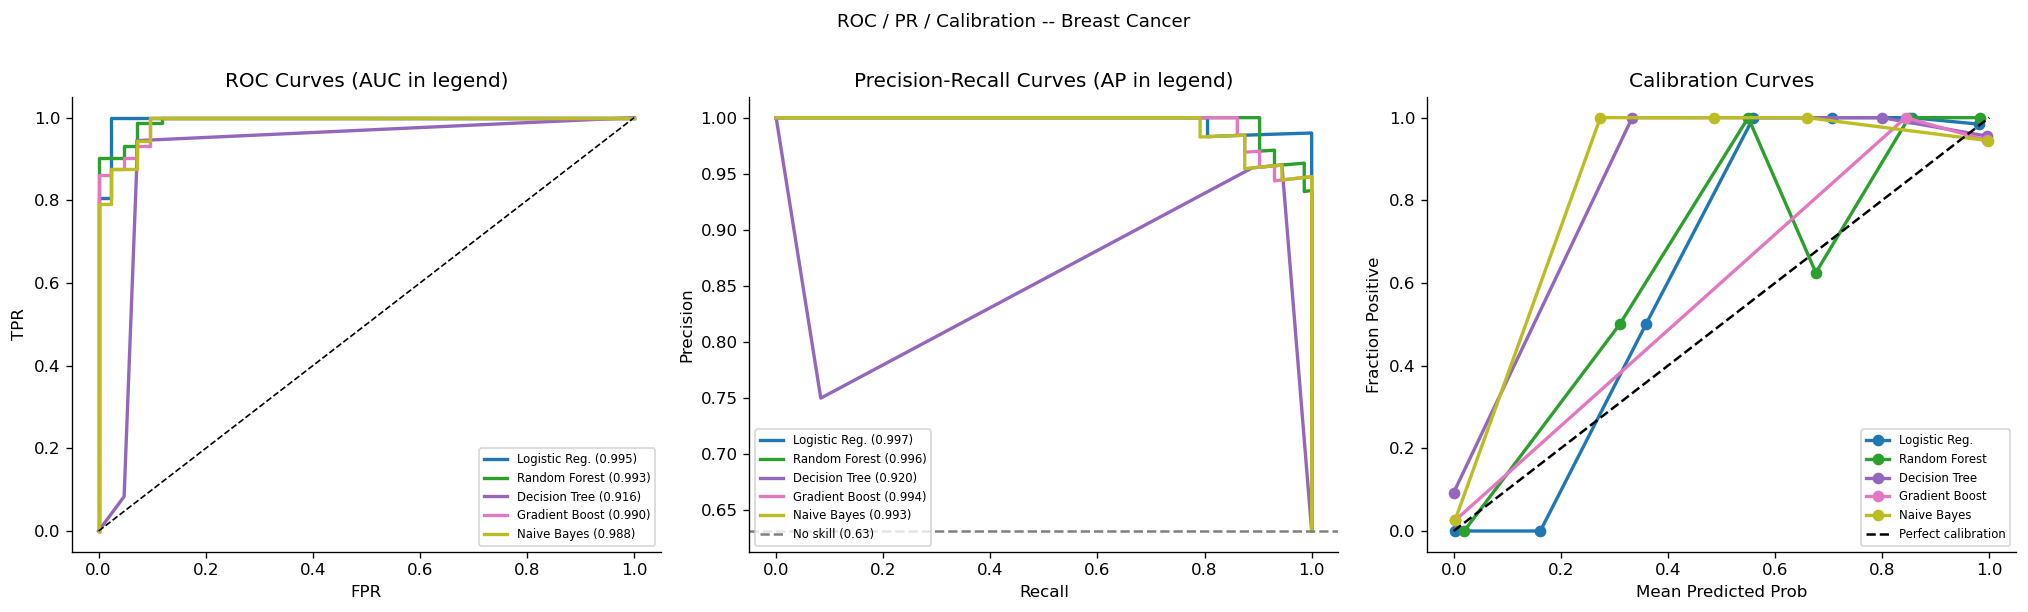

In [3]:
# ROC, Precision-Recall, and Calibration curves
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
palette = plt.cm.tab10(np.linspace(0, 0.8, len(models_eval)))

for (name, model), color in zip(models_eval.items(), palette):
    ypr = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, ypr)
    axes[0].plot(fpr, tpr, lw=2, label=f'{name} ({auc(fpr,tpr):.3f})', color=color)
    prec, rec, _ = precision_recall_curve(y_test, ypr)
    axes[1].plot(rec, prec, lw=2,
                 label=f'{name} ({average_precision_score(y_test, ypr):.3f})', color=color)

axes[0].plot([0,1],[0,1],'k--',lw=1); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curves (AUC in legend)'); axes[0].legend(fontsize=7)

axes[1].axhline(y_test.mean(), color='gray', linestyle='--',
                label=f'No skill ({y_test.mean():.2f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves (AP in legend)'); axes[1].legend(fontsize=7)

for (name, model), color in zip(models_eval.items(), palette):
    ypr = model.predict_proba(X_test)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test, ypr, n_bins=8)
    axes[2].plot(mean_pred, frac_pos, 'o-', lw=2, label=name, color=color)
axes[2].plot([0,1],[0,1],'k--',lw=1.5, label='Perfect calibration')
axes[2].set_xlabel('Mean Predicted Prob'); axes[2].set_ylabel('Fraction Positive')
axes[2].set_title('Calibration Curves'); axes[2].legend(fontsize=7)

plt.suptitle('ROC / PR / Calibration -- Breast Cancer', fontsize=11, y=1.01)
plt.tight_layout(); plt.show()


In [4]:
# Why accuracy fails on imbalanced data
np.random.seed(SEED)
X_imb, y_imb = make_classification(
    n_samples=1000, n_features=20, n_informative=5,
    weights=[0.95, 0.05], random_state=SEED)
X_ti, X_tei, y_ti, y_tei = train_test_split(
    X_imb, y_imb, test_size=0.2, random_state=SEED, stratify=y_imb)

majority_pred = np.zeros(len(y_tei), dtype=int)
rf_imb = RandomForestClassifier(n_estimators=100, random_state=SEED)
rf_imb.fit(X_ti, y_ti)
rf_pred = rf_imb.predict(X_tei)

print('-- Imbalanced Data (5 pct positive class) --')
print(f'Class counts in test set: {np.bincount(y_tei)}')
print()
print(f'{"Metric":<18} {"Majority Clf":>18} {"Random Forest":>16}')
print('-' * 55)
for metric, fn_maj, fn_rf in [
    ('Accuracy', accuracy_score(y_tei, majority_pred), accuracy_score(y_tei, rf_pred)),
    ('F1',       f1_score(y_tei, majority_pred, zero_division=0), f1_score(y_tei, rf_pred)),
    ('MCC',      mcc_score(y_tei, majority_pred), mcc_score(y_tei, rf_pred)),
    ('AUC-ROC',  0.5, roc_auc_score(y_tei, rf_imb.predict_proba(X_tei)[:,1])),
]:
    print(f'{metric:<18} {fn_maj:>18.4f} {fn_rf:>16.4f}')

print()
print('Conclusion: Accuracy = 95 pct for a trivial model that never predicts the minority.')
print('Use MCC, F1, or AUC-PR for imbalanced classification tasks.')


-- Imbalanced Data (5 pct positive class) --
Class counts in test set: [189  11]

Metric                   Majority Clf    Random Forest
-------------------------------------------------------
Accuracy                       0.9450           0.9650
F1                             0.0000           0.5333
MCC                            0.0000           0.5922
AUC-ROC                        0.5000           0.9488

Conclusion: Accuracy = 95 pct for a trivial model that never predicts the minority.
Use MCC, F1, or AUC-PR for imbalanced classification tasks.


### Interpretation

- **Accuracy is 95% for a classifier that never predicts the minority class** - it is an unreliable metric when classes are imbalanced.
- **MCC** accounts for all four confusion matrix cells symmetrically and is the most reliable single metric for binary classification under any class distribution.
- **AUC-PR** is more informative than AUC-ROC under severe imbalance because ROC curves are insensitive to the abundance of true negatives.
- **Calibration curves** reveal whether predicted probabilities match empirical frequencies, which is critical for threshold-sensitive or risk-sensitive decisions.


---
# 2. Regression Metrics

| Metric | Formula | Properties |
|---|---|---|
| MSE | $\frac{1}{n}\sum_i(y_i-\hat{y}_i)^2$ | Penalizes large errors quadratically |
| RMSE | $\sqrt{\text{MSE}}$ | Same units as $y$; interpretable |
| MAE | $\frac{1}{n}\sum_i|y_i-\hat{y}_i|$ | Robust to outliers; L1 loss |
| $R^2$ | $1 - SS_{res}/SS_{tot}$ | Fraction of variance explained; can be negative |
| Adj. $R^2$ | $1-(1-R^2)(n-1)/(n-p-1)$ | Penalizes additional predictors |
| sMAPE | $\frac{200\%}{n}\sum|e_i|/(|y_i|+|\hat{y}_i|)$ | Scale-independent; symmetric; handles zeros |


-- Regression Metrics: Diabetes Dataset --
                  RMSE     MAE      R2  Adj.R2   sMAPE
Model                                                 
OLS Linear      53.853  42.794  0.4526  0.3824  31.703
Ridge (lam=1)   55.474  46.139  0.4192  0.3447  34.079
Random Forest   54.461  44.276  0.4402  0.3684  33.263
Gradient Boost  54.633  44.795  0.4366  0.3644  33.380


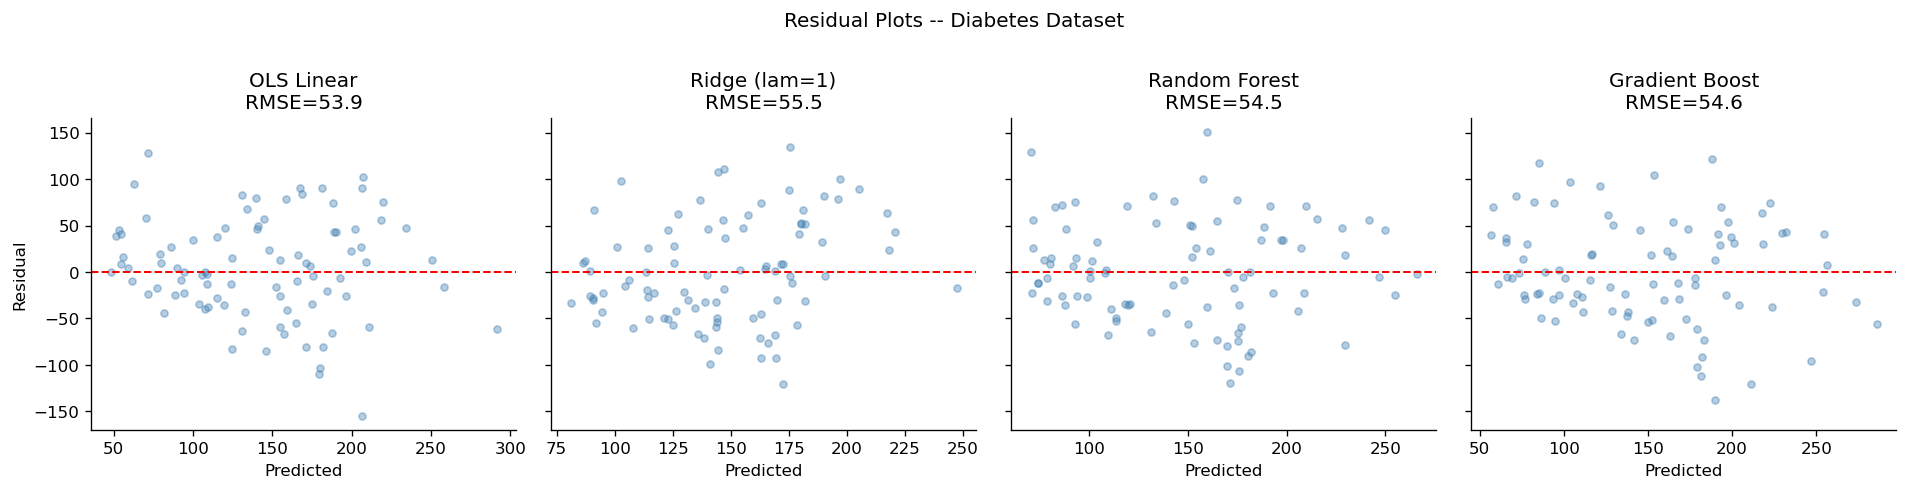

In [5]:
data = load_diabetes()
X_r, y_r = data.data, data.target
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X_r, y_r, test_size=0.2, random_state=SEED)

def smape(y_true, y_pred):
    return 200 * np.mean(np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8))

reg_models = {
    'OLS Linear':     LinearRegression(),
    'Ridge (lam=1)':  Ridge(alpha=1.0),
    'Random Forest':  RandomForestRegressor(n_estimators=200, random_state=SEED),
    'Gradient Boost': GradientBoostingRegressor(n_estimators=200, random_state=SEED),
}

reg_rows = []
for name, model in reg_models.items():
    model.fit(X_tr_r, y_tr_r)
    yp = model.predict(X_te_r)
    n, p = len(y_te_r), X_te_r.shape[1]
    r2 = r2_score(y_te_r, yp)
    reg_rows.append({
        'Model': name,
        'RMSE':    round(np.sqrt(mean_squared_error(y_te_r, yp)), 3),
        'MAE':     round(mean_absolute_error(y_te_r, yp), 3),
        'R2':      round(r2, 4),
        'Adj.R2':  round(1-(1-r2)*(n-1)/(n-p-1), 4),
        'sMAPE':   round(smape(y_te_r, yp), 3),
    })

df_reg = pd.DataFrame(reg_rows).set_index('Model')
print('-- Regression Metrics: Diabetes Dataset --')
print(df_reg.to_string())

# Residual plots
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, (name, model) in zip(axes, reg_models.items()):
    yp = model.predict(X_te_r)
    residuals = y_te_r - yp
    ax.scatter(yp, residuals, alpha=0.4, s=18, color='steelblue')
    ax.axhline(0, color='red', lw=1.2, linestyle='--')
    ax.set_title(f'{name}\nRMSE={np.sqrt(mean_squared_error(y_te_r,yp)):.1f}')
    ax.set_xlabel('Predicted')
axes[0].set_ylabel('Residual')
plt.suptitle('Residual Plots -- Diabetes Dataset', fontsize=12, y=1.01)
plt.tight_layout(); plt.show()


---
# 3. Cross-Validation Design

> Match the CV strategy to the data structure. Wrong CV produces optimistically biased estimates.

| Strategy | When to use | Key property |
|---|---|---|
| $k$-Fold | Standard tabular data | Average over $k$ train/test splits |
| Stratified $k$-Fold | Classification | Preserves class proportions per fold |
| Repeated $k$-Fold | Small datasets | Reduces CV variance via multiple repeats |
| Time-Series CV | Temporal data | Test fold always after train fold |
| **Nested CV** | Hyperparameter tuning | Outer: evaluate; Inner: tune. Prevents optimistic bias |


-- Nested vs Non-Nested Cross-Validation --
Nested CV    AUC-ROC: 0.9936 +/- 0.0097
Non-Nested   AUC-ROC: 0.9953 +/- 0.0053
Optimistic bias:      0.0017


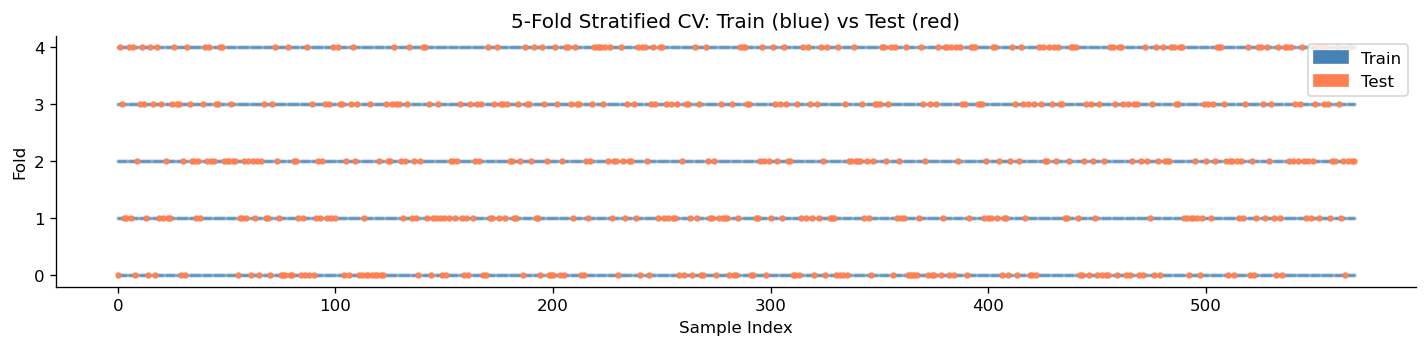

In [6]:
# Nested CV demonstration: unbiased estimate when tuning hyperparameters
cancer = load_breast_cancer()
X_cv, y_cv = cancer.data, cancer.target

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
inner_cv  = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

# Nested: tune C inside each outer fold, evaluate on held-out outer fold
clf_gs = GridSearchCV(
    Pipeline([('sc', StandardScaler()), ('lr', LogisticRegression(max_iter=1000, random_state=SEED))]),
    param_grid={'lr__C': [0.01, 0.1, 1.0, 10.0]},
    cv=inner_cv, scoring='roc_auc', n_jobs=-1
)
nested_scores = cross_validate(clf_gs, X_cv, y_cv, cv=outer_cv,
                               scoring='roc_auc', return_train_score=True)

# Non-nested: tune on full data, evaluate by CV (leaky)
clf_fixed = Pipeline([('sc', StandardScaler()),
                      ('lr', LogisticRegression(C=1.0, max_iter=1000, random_state=SEED))])
naive_scores = cross_val_score(clf_fixed, X_cv, y_cv, cv=outer_cv, scoring='roc_auc')

print('-- Nested vs Non-Nested Cross-Validation --')
print(f'Nested CV    AUC-ROC: {nested_scores["test_score"].mean():.4f}'
      f' +/- {nested_scores["test_score"].std():.4f}')
print(f'Non-Nested   AUC-ROC: {naive_scores.mean():.4f}'
      f' +/- {naive_scores.std():.4f}')
print(f'Optimistic bias:      {naive_scores.mean() - nested_scores["test_score"].mean():.4f}')

# Visualize fold structure
fig, ax = plt.subplots(figsize=(12, 3))
from matplotlib.patches import Patch
for fold, (tr_idx, te_idx) in enumerate(outer_cv.split(X_cv, y_cv)):
    ax.scatter(tr_idx, [fold]*len(tr_idx), c='steelblue', s=2, alpha=0.5)
    ax.scatter(te_idx, [fold]*len(te_idx), c='coral',     s=8, alpha=0.9)
ax.set_xlabel('Sample Index'); ax.set_ylabel('Fold')
ax.set_title('5-Fold Stratified CV: Train (blue) vs Test (red)')
ax.legend(handles=[Patch(color='steelblue', label='Train'),
                    Patch(color='coral',     label='Test')])
plt.tight_layout(); plt.show()


---
# 4. Statistical Significance Testing

| Scenario | Test | Assumption |
|---|---|---|
| 2 algorithms, 1 dataset, $k$-fold | Paired $t$-test | Fold-score differences approx. normal |
| 2 algorithms, 1 dataset, robust | Wilcoxon signed-rank | No normality assumption |
| 2 classifiers, same test set | McNemar's test | Disagreement count table |
| $>$2 algorithms, multiple datasets | Friedman + Nemenyi | Non-parametric rank test |
| Many pairwise comparisons | Holm-Bonferroni / BH correction | FWER / FDR control |

> **Always report effect sizes alongside $p$-values.** With large $n$, trivially small differences can achieve statistical significance while having negligible practical importance.


In [7]:
# Paired t-test and Wilcoxon: GBM vs RF on breast cancer
cancer = load_breast_cancer()
X_st, y_st = cancer.data, cancer.target
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

scores_rf  = cross_val_score(
    RandomForestClassifier(n_estimators=200, random_state=SEED),
    X_st, y_st, cv=cv10, scoring='roc_auc')
scores_gbm = cross_val_score(
    GradientBoostingClassifier(n_estimators=200, random_state=SEED),
    X_st, y_st, cv=cv10, scoring='roc_auc')

diffs = scores_gbm - scores_rf
t_stat,  p_ttest  = stats.ttest_rel(scores_gbm, scores_rf)
w_stat,  p_wilcox = stats.wilcoxon(scores_gbm, scores_rf, alternative='two-sided')
cohen_d = diffs.mean() / diffs.std()

print('-- Statistical Tests: GBM vs RF (10-fold CV, Breast Cancer) --')
print(f'{'':30s} {'GBM':>10} {'RF':>10} {'Diff':>10}')
print(f'{'Mean AUC-ROC':<30} {scores_gbm.mean():>10.4f} {scores_rf.mean():>10.4f} {diffs.mean():>+10.4f}')
print(f'{'Std  AUC-ROC':<30} {scores_gbm.std():>10.4f} {scores_rf.std():>10.4f}')
print()
print(f"Paired t-test:         t={t_stat:+.4f}  p={p_ttest:.4f}  {'*' if p_ttest<0.05 else '(ns)'}")
print(f"Wilcoxon signed-rank:  W={w_stat:.0f}      p={p_wilcox:.4f}  {'*' if p_wilcox<0.05 else '(ns)'}")
size = 'large' if abs(cohen_d)>0.8 else 'medium' if abs(cohen_d)>0.5 else 'small'
print(f"Cohen's d (effect):    {cohen_d:.4f}  ({size})")


-- Statistical Tests: GBM vs RF (10-fold CV, Breast Cancer) --
                                      GBM         RF       Diff
Mean AUC-ROC                       0.9926     0.9907    +0.0019
Std  AUC-ROC                       0.0091     0.0125

Paired t-test:         t=+1.0915  p=0.3034  (ns)
Wilcoxon signed-rank:  W=12      p=0.4766  (ns)
Cohen's d (effect):    0.3638  (small)


Friedman test: chi2=5.7778  p=0.2164
Bonferroni threshold: 0.00500
  LR   vs RF  : p=0.5000    ns
  LR   vs GBM : p=1.0000    ns
  LR   vs DT  : p=0.5000    ns
  LR   vs NB  : p=0.5000    ns
  RF   vs GBM : p=1.0000    ns
  RF   vs DT  : p=1.0000    ns
  RF   vs NB  : p=1.0000    ns
  GBM  vs DT  : p=0.5000    ns
  GBM  vs NB  : p=0.5000    ns
  DT   vs NB  : p=1.0000    ns


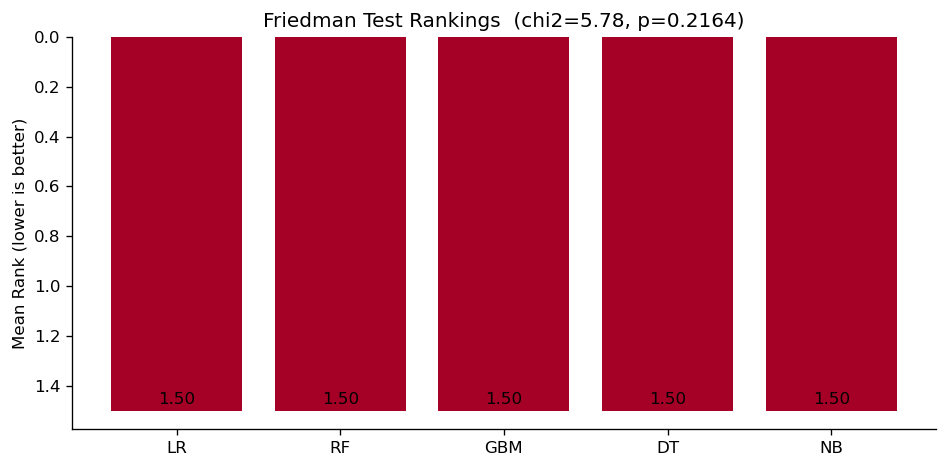

In [8]:
# Friedman test across multiple algorithms and datasets
datasets_mc = {'Breast Cancer': load_breast_cancer(), 'Iris': load_iris()}
algos_mc    = {
    'LR':  Pipeline([('sc', StandardScaler()), ('m', LogisticRegression(max_iter=1000, random_state=SEED))]),
    'RF':  RandomForestClassifier(n_estimators=100, random_state=SEED),
    'GBM': GradientBoostingClassifier(n_estimators=100, random_state=SEED),
    'DT':  DecisionTreeClassifier(max_depth=5, random_state=SEED),
    'NB':  GaussianNB(),
}
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Collect mean accuracy per (algorithm, dataset)
score_matrix = []
for ds_name, ds in datasets_mc.items():
    X_mc, y_mc = ds.data, ds.target
    row = []
    for algo in algos_mc.values():
        s = cross_val_score(algo, X_mc, y_mc, cv=cv5, scoring='accuracy')
        row.append(s.mean())
    score_matrix.append(row)

score_matrix = np.array(score_matrix)  # shape: (n_datasets, n_algos)
friedman_stat, p_friedman = stats.friedmanchisquare(*score_matrix.T)
print(f'Friedman test: chi2={friedman_stat:.4f}  p={p_friedman:.4f}')

# Pairwise Wilcoxon with Bonferroni correction
algo_names = list(algos_mc.keys())
pairs = list(combinations(range(len(algo_names)), 2))
p_vals = [stats.wilcoxon(score_matrix[:,i], score_matrix[:,j])[1]
          for i, j in pairs]
bonf = 0.05 / len(pairs)
print(f'Bonferroni threshold: {bonf:.5f}')
for (i, j), p in zip(pairs, p_vals):
    sig = '* sig' if p < bonf else '  ns'
    print(f'  {algo_names[i]:4s} vs {algo_names[j]:4s}: p={p:.4f}  {sig}')

# Mean rank chart
from scipy.stats import rankdata
ranks = np.array([rankdata(-score_matrix[:,a]) for a in range(len(algo_names))]).T
mean_ranks = ranks.mean(axis=0)
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(algo_names, mean_ranks,
              color=plt.cm.RdYlGn_r(mean_ranks / mean_ranks.max()))
ax.bar_label(bars, fmt='%.2f', padding=2)
ax.invert_yaxis()
ax.set_ylabel('Mean Rank (lower is better)')
ax.set_title(f'Friedman Test Rankings  (chi2={friedman_stat:.2f}, p={p_friedman:.4f})')
plt.tight_layout(); plt.show()


### Interpretation

- Paired tests use fold-level scores as matched pairs, controlling for dataset difficulty
  variation and making the test more powerful than an unpaired test.
- **Cohen's d** measures practical significance: small ($d < 0.5$), medium ($d < 0.8$), large ($d \geq 0.8$).
- **Bonferroni correction** is conservative for many comparisons; use Holm-Bonferroni for greater power.
- **Friedman + Nemenyi** is the standard approach for comparing more than two algorithms across
  multiple datasets, as recommended by Demsar (2006).


---
# 5. Fairness-Aware Assessment

For protected attribute $A$ (e.g., gender, race):

| Criterion | Definition |
|---|---|
| Demographic parity | $P(\hat{Y}=1|A=0) = P(\hat{Y}=1|A=1)$ |
| Equal opportunity | $P(\hat{Y}=1|Y=1,A=0) = P(\hat{Y}=1|Y=1,A=1)$ |
| Equalized odds | TPR and FPR equal across groups |

> These three criteria are **mutually incompatible** when base rates differ across groups (Chouldechova, 2017). The appropriate criterion is determined by regulatory context and the relative costs of false positives vs. false negatives in the application domain.


In [9]:
# Synthetic loan approval dataset
np.random.seed(SEED)
n_fair = 1000
group = np.random.choice([0, 1], n_fair, p=[0.4, 0.6])
income = np.where(group==1, np.random.normal(65,15,n_fair), np.random.normal(55,18,n_fair))
credit = np.where(group==1, np.random.normal(680,80,n_fair), np.random.normal(640,90,n_fair))
true_prob = 1/(1 + np.exp(-(0.02*credit + 0.01*income - 17)))
y_fair = (np.random.rand(n_fair) < true_prob).astype(int)

X_fair = np.column_stack([income, credit])
X_tf, X_tef, y_tf, y_tef, g_tf, g_tef = train_test_split(
    X_fair, y_fair, group, test_size=0.3, random_state=SEED)

clf_fair = Pipeline([('sc', StandardScaler()),
                     ('lr', LogisticRegression(max_iter=1000, random_state=SEED))])
clf_fair.fit(X_tf, y_tf)
y_pred_f = clf_fair.predict(X_tef)

# Fairness report
rows_f = []
for g, gname in [(0,'Minority (A=0)'), (1,'Majority (A=1)')]:
    mask = g_tef == g
    yt, yp = y_tef[mask], y_pred_f[mask]
    cm_g = confusion_matrix(yt, yp, labels=[0,1])
    TP, FP, FN, TN = cm_g[1,1], cm_g[0,1], cm_g[1,0], cm_g[0,0]
    tpr = TP/(TP+FN) if (TP+FN)>0 else 0
    fpr = FP/(FP+TN) if (FP+TN)>0 else 0
    rows_f.append({'Group': gname, 'n': mask.sum(),
                   'Base Rate':     round(yt.mean(), 4),
                   'Pred Pos Rate': round(yp.mean(), 4),
                   'TPR':           round(tpr, 4),
                   'FPR':           round(fpr, 4),
                   'Accuracy':      round(accuracy_score(yt,yp), 4)})

df_fair = pd.DataFrame(rows_f).set_index('Group')
print('-- Fairness Report: Loan Approval --')
print(df_fair.to_string())

ppr0 = df_fair.loc['Minority (A=0)', 'Pred Pos Rate']
ppr1 = df_fair.loc['Majority (A=1)', 'Pred Pos Rate']
tpr0 = df_fair.loc['Minority (A=0)', 'TPR']
tpr1 = df_fair.loc['Majority (A=1)', 'TPR']
print(f'\nDisparate Impact Ratio (PPR_min/PPR_maj): {ppr0/ppr1:.4f}')
print(f'  (< 0.80 triggers regulatory scrutiny under the 80 pct rule)')
print(f'Equal Opportunity Gap (TPR_maj - TPR_min): {tpr1 - tpr0:+.4f}')


-- Fairness Report: Loan Approval --
                  n  Base Rate  Pred Pos Rate   TPR     FPR  Accuracy
Group                                                                
Minority (A=0)  132     0.0455         0.0076  0.00  0.0079     0.947
Majority (A=1)  168     0.1190         0.0119  0.05  0.0068     0.881

Disparate Impact Ratio (PPR_min/PPR_maj): 0.6387
  (< 0.80 triggers regulatory scrutiny under the 80 pct rule)
Equal Opportunity Gap (TPR_maj - TPR_min): +0.0500


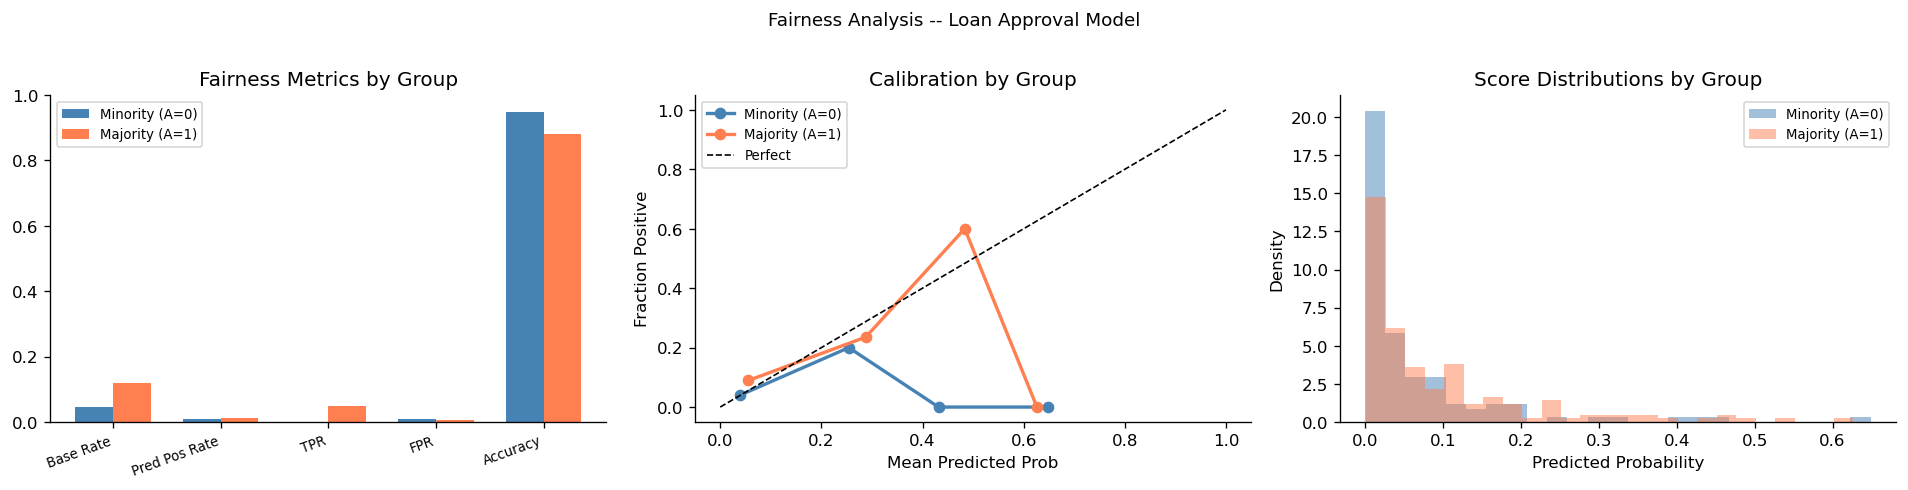

In [10]:
# Fairness visualization
palette_f = ['steelblue', 'coral']
groups_f  = df_fair.index.tolist()
metrics_f = ['Base Rate', 'Pred Pos Rate', 'TPR', 'FPR', 'Accuracy']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

x_f = np.arange(len(metrics_f)); w_f = 0.35
for i, (gname, color) in enumerate(zip(groups_f, palette_f)):
    vals = df_fair.loc[gname, metrics_f].values.astype(float)
    axes[0].bar(x_f + i*w_f, vals, w_f, label=gname, color=color)
axes[0].set_xticks(x_f + w_f/2)
axes[0].set_xticklabels(metrics_f, rotation=20, ha='right', fontsize=8)
axes[0].set_ylim(0, 1); axes[0].set_title('Fairness Metrics by Group'); axes[0].legend(fontsize=8)

for g, color, gname in zip([0,1], palette_f, groups_f):
    mask = g_tef == g
    ypr_g = clf_fair.predict_proba(X_tef[mask])[:, 1]
    frac, mean_p = calibration_curve(y_tef[mask], ypr_g, n_bins=5)
    axes[1].plot(mean_p, frac, 'o-', color=color, lw=2, label=gname)
axes[1].plot([0,1],[0,1],'k--',lw=1, label='Perfect')
axes[1].set_xlabel('Mean Predicted Prob'); axes[1].set_ylabel('Fraction Positive')
axes[1].set_title('Calibration by Group'); axes[1].legend(fontsize=8)

for g, color, gname in zip([0,1], palette_f, groups_f):
    mask = g_tef == g
    ypr_g = clf_fair.predict_proba(X_tef[mask])[:, 1]
    axes[2].hist(ypr_g, bins=25, alpha=0.5, color=color, label=gname, density=True)
axes[2].set_xlabel('Predicted Probability'); axes[2].set_ylabel('Density')
axes[2].set_title('Score Distributions by Group'); axes[2].legend(fontsize=8)

plt.suptitle('Fairness Analysis -- Loan Approval Model', fontsize=11, y=1.01)
plt.tight_layout(); plt.show()


### Interpretation

- A **Disparate Impact Ratio below 0.80** triggers regulatory review. A ratio of 1.0 indicates perfect demographic parity.
- The **Equal Opportunity Gap** measures whether qualified applicants in both groups have the same probability of being correctly approved - relevant when false negatives carry higher harm.
- **Score distribution plots** reveal whether the model systematically assigns lower scores to the minority group, even after controlling for credit-relevant features.
- Fairness-accuracy trade-offs are real: enforcing exact demographic parity may require accepting lower accuracy. The correct trade-off is determined by legal requirements and the ethical framework of the application domain.
